In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

#### 1. EDA

In [3]:
df_train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [4]:
df_train.shape

(891, 12)

In [5]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train) * 100).round(1)

In [9]:
missing_df = pd.DataFrame({
    'Missing count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing count'] > 0])

          Missing count  Missing %
Cabin               687       77.1
Age                 177       19.9
Embarked              2        0.2


Overall survival rate: 38.4%
Survived
0    549
1    342
Name: count, dtype: int64


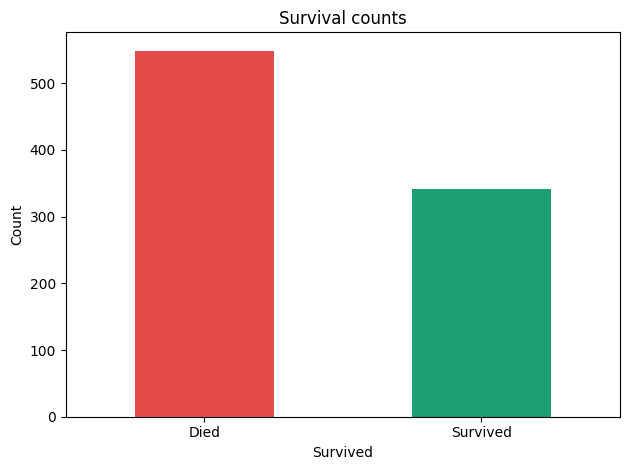

In [10]:
print(f"Overall survival rate: {df_train['Survived'].mean():.1%}")
print(df_train['Survived'].value_counts())

df_train['Survived'].value_counts().plot(kind='bar', color=['#E24B4A','#1D9E75'])
plt.title('Survival counts')
plt.xticks([0,1], ['Died','Survived'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('survival_counts.png', dpi=150)
plt.show()

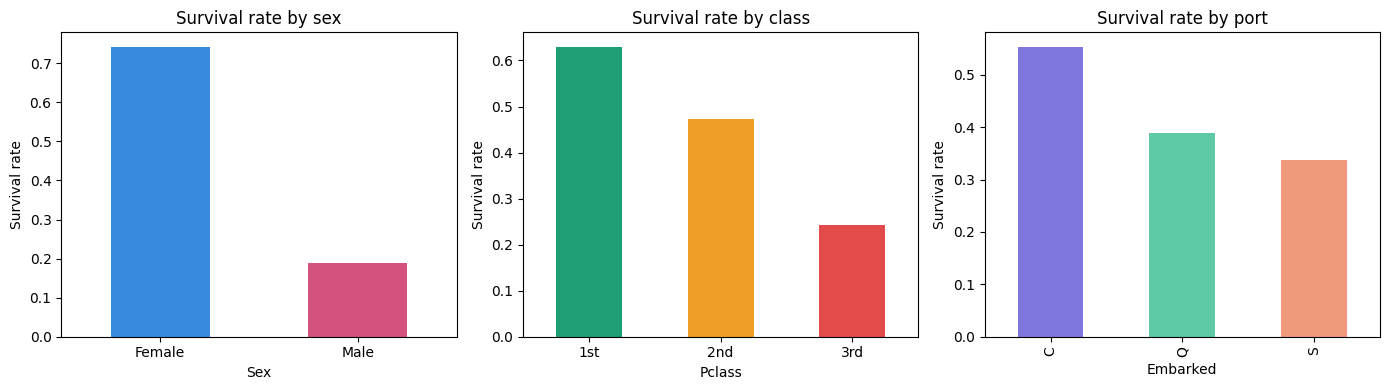

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# By Sex
df_train.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0], color=['#378ADD','#D4537E'])
axes[0].set_title('Survival rate by sex')
axes[0].set_ylabel('Survival rate')
axes[0].set_xticklabels(['Female','Male'], rotation=0)

# By Pclass
df_train.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color=['#1D9E75','#EF9F27','#E24B4A'])
axes[1].set_title('Survival rate by class')
axes[1].set_ylabel('Survival rate')
axes[1].set_xticklabels(['1st','2nd','3rd'], rotation=0)

# By Embarked
df_train.groupby('Embarked')['Survived'].mean().plot(
    kind='bar', ax=axes[2], color=['#7F77DD','#5DCAA5','#F0997B'])
axes[2].set_title('Survival rate by port')
axes[2].set_ylabel('Survival rate')

plt.tight_layout()
plt.savefig('survival_by_features.png', dpi=150)
plt.show()

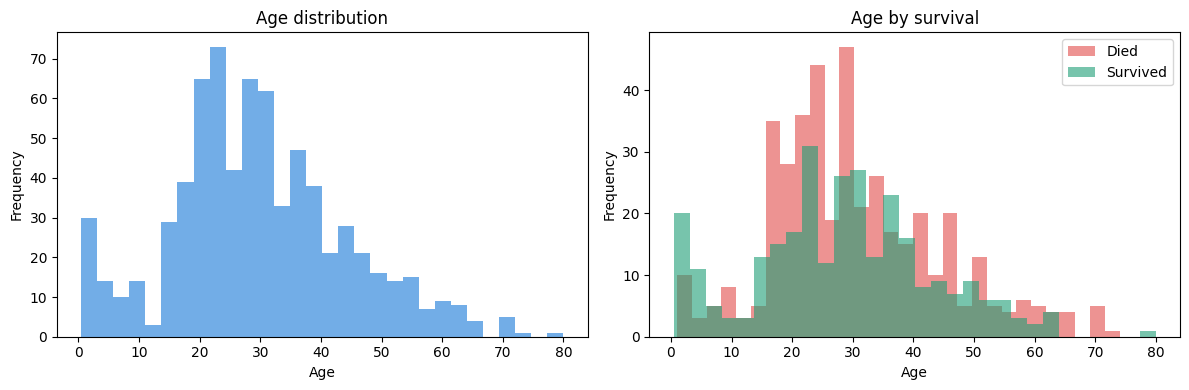

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall age distribution
df_train['Age'].dropna().plot(kind='hist', bins=30, ax=axes[0], color='#378ADD', alpha=0.7)
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

# Age by survival
df_train[df_train['Survived']==0]['Age'].dropna().plot(
    kind='hist', bins=30, ax=axes[1], alpha=0.6, label='Died', color='#E24B4A')
df_train[df_train['Survived']==1]['Age'].dropna().plot(
    kind='hist', bins=30, ax=axes[1], alpha=0.6, label='Survived', color='#1D9E75')
axes[1].set_title('Age by survival')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150)
plt.show()

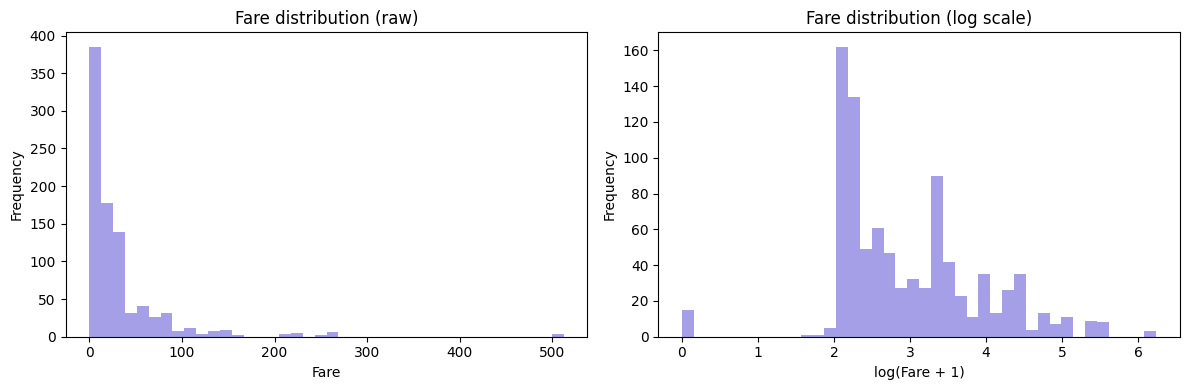

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train['Fare'].plot(kind='hist', bins=40, ax=axes[0], color='#7F77DD', alpha=0.7)
axes[0].set_title('Fare distribution (raw)')
axes[0].set_xlabel('Fare')

np.log1p(df_train['Fare']).plot(kind='hist', bins=40, ax=axes[1], color='#7F77DD', alpha=0.7)
axes[1].set_title('Fare distribution (log scale)')
axes[1].set_xlabel('log(Fare + 1)')

plt.tight_layout()
plt.savefig('fare_distribution.png', dpi=150)
plt.show()

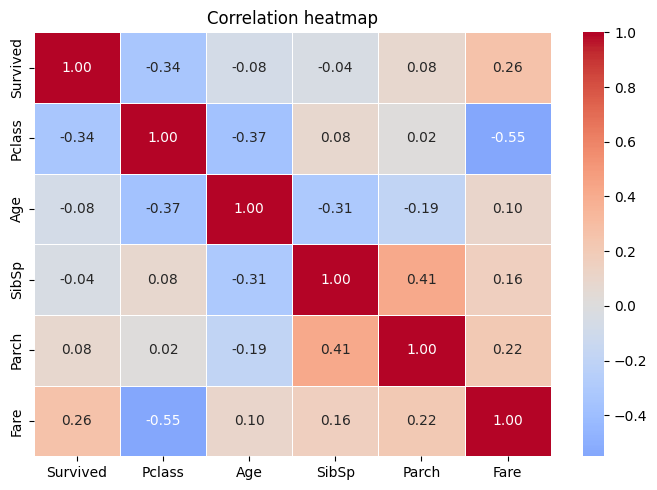

In [14]:
numeric_cols = ['Survived','Pclass','Age','SibSp','Parch','Fare']

plt.figure(figsize=(7, 5))
sns.heatmap(
    df_train[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

#### 2. Handle missing values

In [15]:
print(f"Survival rate — Female : {df_train[df_train['Sex']=='female']['Survived'].mean():.1%}")
print(f"Survival rate — Male   : {df_train[df_train['Sex']=='male']['Survived'].mean():.1%}")
print(f"Survival rate — 1st cls: {df_train[df_train['Pclass']==1]['Survived'].mean():.1%}")
print(f"Survival rate — 3rd cls: {df_train[df_train['Pclass']==3]['Survived'].mean():.1%}")
print(f"Median age (survived)  : {df_train[df_train['Survived']==1]['Age'].median():.1f}")
print(f"Median age (died)      : {df_train[df_train['Survived']==0]['Age'].median():.1f}")

Survival rate — Female : 74.2%
Survival rate — Male   : 18.9%
Survival rate — 1st cls: 63.0%
Survival rate — 3rd cls: 24.2%
Median age (survived)  : 28.0
Median age (died)      : 28.0


In [16]:
audit = pd.DataFrame({
    'Missing count': missing,
    'Missing %': missing_pct,
    'Dtype': df_train.dtypes
}).query('`Missing count` > 0')

print(audit)

          Missing count  Missing %    Dtype
Age                 177       19.9  float64
Cabin               687       77.1   object
Embarked              2        0.2   object


In [17]:
# Check median before imputing
print(f"Age median: {df_train['Age'].median()}")        # 28.0
print(f"Age mean:   {df_train['Age'].mean():.1f}")      # 29.7

# Impute with median (robust to the few very old passengers)
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

# Verify
print(f"Age missing after: {df_train['Age'].isnull().sum()}")  # 0

Age median: 28.0
Age mean:   29.7
Age missing after: 0


In [18]:
# First, extract the information that IS available
df_train['HasCabin'] = df_train['Cabin'].notnull().astype(int)

# Check if HasCabin correlates with survival (it does — cabin = 1st class proximity)
print(df_train.groupby('HasCabin')['Survived'].mean())
# HasCabin=0 → ~30% survival
# HasCabin=1 → ~67% survival

# Now drop the raw Cabin column
df_train.drop(columns=['Cabin'], inplace=True)

HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


In [19]:
# See the 2 missing rows
print(df_train[df_train['Embarked'].isnull()])

# Check mode
print(df_train['Embarked'].value_counts())
# S    644  ← most common
# C    168
# Q     77

# Fill with mode
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

# Verify
print(f"Embarked missing after: {df_train['Embarked'].isnull().sum()}")  # 0

     PassengerId  Survived  Pclass                                       Name  \
61            62         1       1                        Icard, Miss. Amelie   
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch  Ticket  Fare Embarked  HasCabin  
61   female  38.0      0      0  113572  80.0      NaN         1  
829  female  62.0      0      0  113572  80.0      NaN         1  
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Embarked missing after: 0


In [20]:
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])
# Age       86
# Fare       1   ← NEW — not in train.csv
# Cabin    327

Age       86
Fare       1
Cabin    327
dtype: int64


In [21]:
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())

In [22]:
# Apply all the same steps to test set too, then verify both
print("Train missing:")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])   # should be empty

print("\nTest missing:")
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])  # should be empty

Train missing:
Series([], dtype: int64)

Test missing:
Age       86
Cabin    327
dtype: int64


In [23]:
# Group-wise median imputation for Age
df_train['Age'] = df_train.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

#### 3. Feature engineering

In [24]:
# Extract title using regex
df_train['Title'] = df_train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# See all titles
print(df_train['Title'].value_counts())
# Mr        517
# Miss      182
# Mrs       125
# Master     40
# Dr          7
# Rev         6
# ... rare ones

# Group rare titles
df_train['Title'] = df_train['Title'].replace(
    ['Dr','Rev','Col','Major','Mlle','Countess',
     'Ms','Lady','Jonkheer','Don','Dona','Capt','Sir'],
    'Rare'
)
df_train['Title'] = df_train['Title'].replace({'Mme': 'Mrs', 'Ms': 'Miss'})

# Check survival rate by title — very revealing
print(df_train.groupby('Title')['Survived'].mean().round(2))
# Master    0.58   ← boys, high survival
# Miss      0.70   ← women, high survival
# Mr        0.16   ← men, very low survival
# Mrs       0.79   ← married women, highest survival
# Rare      0.35

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
Title
Master    0.57
Miss      0.70
Mr        0.16
Mrs       0.79
Rare      0.42
Name: Survived, dtype: float64


In [25]:
# Total family members aboard (including self)
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1

# Check survival by family size
print(df_train.groupby('FamilySize')['Survived'].mean().round(2))
# 1    0.30  ← alone, low survival
# 2    0.55  ← small family, best survival
# 3    0.58
# 4    0.72
# 5    0.20  ← large family, hard to move together
# 6    0.14
# 7    0.33
# 8    0.00
# 11   0.00

# Binary flag — being alone is a strong negative signal
df_train['IsAlone'] = (df_train['FamilySize'] == 1).astype(int)

print(df_train.groupby('IsAlone')['Survived'].mean())
# IsAlone=0 → ~50% survival
# IsAlone=1 → ~30% survival

FamilySize
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: Survived, dtype: float64
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


In [26]:
df_train['AgeBand'] = pd.cut(df_train['Age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child','Teen','YoungAdult','Adult','Senior'])

print(df_train.groupby('AgeBand')['Survived'].mean().round(2))
# Child       0.54  ← children had higher survival
# Teen        0.40
# YoungAdult  0.37
# Adult       0.40
# Senior      0.34

AgeBand
Child         0.58
Teen          0.43
YoungAdult    0.35
Adult         0.40
Senior        0.23
Name: Survived, dtype: float64


In [27]:
df_train['FareBand'] = pd.qcut(df_train['Fare'], q=4,
                          labels=['Low','Mid','High','VeryHigh'])

print(df_train.groupby('FareBand')['Survived'].mean().round(2))
# Low       0.20
# Mid       0.36
# High      0.45
# VeryHigh  0.58

FareBand
Low         0.20
Mid         0.30
High        0.45
VeryHigh    0.58
Name: Survived, dtype: float64


In [28]:
# Already done — just verify it's there
print(df_train['HasCabin'].value_counts())
print(df_train.groupby('HasCabin')['Survived'].mean())

HasCabin
0    687
1    204
Name: count, dtype: int64
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


In [29]:
df_train.drop(columns=['Name', 'Ticket', 'SibSp', 'Parch', 'Age', 'Fare'],
        inplace=True)

# What's left
print(df_train.columns.tolist())
# ['PassengerId','Survived','Pclass','Sex','Embarked',
#  'HasCabin','Title','FamilySize','IsAlone','AgeBand','FareBand']

['PassengerId', 'Survived', 'Pclass', 'Sex', 'Embarked', 'HasCabin', 'Title', 'FamilySize', 'IsAlone', 'AgeBand', 'FareBand']


In [30]:
# Apply all the same steps using a function
# I am calling its name engineering features
def engineer_features(df):
    # Title
    if 'Name' in df.columns:
        df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        df['Title'] = df['Title'].replace(
            ['Dr','Rev','Col','Major','Mlle','Countess',
             'Ms','Lady','Jonkheer','Don','Dona','Capt','Sir'], 'Rare')
        df['Title'] = df['Title'].replace({'Mme': 'Mrs', 'Ms': 'Miss'})

    # Family
    if 'SibSp' in df.columns and 'Parch' in df.columns:
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Bands
    if 'Age' in df.columns:
        df['AgeBand'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                                labels=['Child','Teen','YoungAdult','Adult','Senior'])
    if 'Fare' in df.columns:
        df['FareBand'] = pd.qcut(df['Fare'], q=4,
                                  labels=['Low','Mid','High','VeryHigh'])

    # Drop only columns that exist
    cols_to_drop = ['Name','Ticket','SibSp','Parch','Age','Fare']
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

    return df

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

## 4. Encode & Scale

In [31]:
print(df_train.dtypes)
print(df_train.head())

PassengerId       int64
Survived          int64
Pclass            int64
Sex              object
Embarked         object
HasCabin          int64
Title            object
FamilySize        int64
IsAlone           int64
AgeBand        category
FareBand       category
dtype: object
   PassengerId  Survived  Pclass     Sex Embarked  HasCabin Title  FamilySize  \
0            1         0       3    male        S         0    Mr           2   
1            2         1       1  female        C         1   Mrs           2   
2            3         1       3  female        S         0  Miss           1   
3            4         1       1  female        S         1   Mrs           2   
4            5         0       3    male        S         0    Mr           1   

   IsAlone     AgeBand  FareBand  
0        0  YoungAdult       Low  
1        0       Adult  VeryHigh  
2        1  YoungAdult       Mid  
3        0  YoungAdult  VeryHigh  
4        1  YoungAdult       Mid  


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Binary columns — simple map
df_train['Sex'] = df_train['Sex'].map({'male': 0, 'female': 1})
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})

# Ordinal columns — map preserving order
embarked_map = {'S': 0, 'C': 1, 'Q': 2}
df_train['Embarked'] = df_train['Embarked'].map(embarked_map)
df_test['Embarked'] = df_test['Embarked'].map(embarked_map)

# Title — label encode (no natural order)
df_train['Title'] = le.fit_transform(df_train['Title'])
df_test['Title'] = le.transform(df_test['Title'])

# AgeBand — map preserving order
age_map = {'Child': 0, 'Teen': 1, 'YoungAdult': 2, 'Adult': 3, 'Senior': 4}
df_train['AgeBand'] = df_train['AgeBand'].map(age_map)
df_test['AgeBand'] = df_test['AgeBand'].map(age_map)

# FareBand — map preserving order
fare_map = {'Low': 0, 'Mid': 1, 'High': 2, 'VeryHigh': 3}
df_train['FareBand'] = df_train['FareBand'].map(fare_map)
df_test['FareBand'] = df_test['FareBand'].map(fare_map)

In [33]:
#Train/test split
from sklearn.model_selection import train_test_split

X = df_train.drop(columns=['Survived', 'PassengerId'])
y = df_train['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")   # (712, 9)
print(f"X_val:   {X_val.shape}")     # (179, 9)
print(f"Survival rate train: {y_train.mean():.2%}")
print(f"Survival rate val:   {y_val.mean():.2%}")
# Both should be ~38% — stratify=y ensures this

X_train: (712, 9)
X_val:   (179, 9)
Survival rate train: 38.34%
Survival rate val:   38.55%


In [34]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Only scale FamilySize — everything else is already 0-4 range
cols_to_scale = ['FamilySize']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale]   = scaler.transform(X_val[cols_to_scale])

# Also prepare the Kaggle test set
X_test = df_test.drop(columns=['PassengerId'])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [35]:
# Final check — confirm everything is numeric and clean
print(X_train.dtypes)       # all should be int64 or float64
print(X_train.isnull().sum()) # all should be 0
print(X_train.shape)        # (712, 9)

Pclass           int64
Sex              int64
Embarked         int64
HasCabin         int64
Title            int64
FamilySize     float64
IsAlone          int64
AgeBand       category
FareBand      category
dtype: object
Pclass        0
Sex           0
Embarked      0
HasCabin      0
Title         0
FamilySize    0
IsAlone       0
AgeBand       0
FareBand      0
dtype: int64
(712, 9)


#### 5. Train models

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

results = {}  # store all results here

def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    val_acc   = accuracy_score(y_v, model.predict(X_v))
    results[name] = {'Train Acc': round(train_acc, 4),
                     'Val Acc':   round(val_acc, 4),
                     'Gap':       round(train_acc - val_acc, 4)}
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Train accuracy : {train_acc:.2%}")
    print(f"  Val accuracy   : {val_acc:.2%}")
    print(f"  Overfit gap    : {train_acc - val_acc:.2%}")
    print(classification_report(y_v, model.predict(X_v),
                                 target_names=['Died','Survived']))
    return model

In [37]:
# Model 1 — Logistic Regression
lr = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, y_train, X_val, y_val
)


  Logistic Regression
  Train accuracy : 81.18%
  Val accuracy   : 81.56%
  Overfit gap    : -0.38%
              precision    recall  f1-score   support

        Died       0.85      0.85      0.85       110
    Survived       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



In [38]:
# Model 2 — Decision Tree
dt = evaluate(
    'Decision Tree',
    DecisionTreeClassifier(random_state=42),
    X_train, y_train, X_val, y_val
)


  Decision Tree
  Train accuracy : 90.59%
  Val accuracy   : 76.54%
  Overfit gap    : 14.05%
              precision    recall  f1-score   support

        Died       0.79      0.84      0.81       110
    Survived       0.71      0.65      0.68        69

    accuracy                           0.77       179
   macro avg       0.75      0.74      0.75       179
weighted avg       0.76      0.77      0.76       179



In [39]:
# Pruned version — much better
dt_pruned = evaluate(
    'Decision Tree (pruned)',
    DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    X_train, y_train, X_val, y_val
)


  Decision Tree (pruned)
  Train accuracy : 85.11%
  Val accuracy   : 79.33%
  Overfit gap    : 5.78%
              precision    recall  f1-score   support

        Died       0.78      0.92      0.85       110
    Survived       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



In [40]:
# Model 3 — Random Forest
rf = evaluate(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train, X_val, y_val
)


  Random Forest
  Train accuracy : 90.59%
  Val accuracy   : 79.33%
  Overfit gap    : 11.26%
              precision    recall  f1-score   support

        Died       0.81      0.86      0.84       110
    Survived       0.76      0.68      0.72        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



In [41]:
# Also check feature importance — very informative
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nFeature importances:")
print(importances.round(3))


Feature importances:
Sex           0.292
Title         0.124
Pclass        0.120
FamilySize    0.107
FareBand      0.107
AgeBand       0.100
HasCabin      0.073
Embarked      0.058
IsAlone       0.021
dtype: float64


In [42]:
# Model 4 — Gradient Boosting
gb = evaluate(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                max_depth=3, random_state=42),
    X_train, y_train, X_val, y_val
)


  Gradient Boosting
  Train accuracy : 86.94%
  Val accuracy   : 79.89%
  Overfit gap    : 7.05%
              precision    recall  f1-score   support

        Died       0.81      0.87      0.84       110
    Survived       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



In [43]:
# Model 5 — SVM
svm = evaluate(
    'SVM',
    SVC(kernel='rbf', C=1.0, random_state=42),
    X_train, y_train, X_val, y_val
)


  SVM
  Train accuracy : 83.43%
  Val accuracy   : 83.24%
  Overfit gap    : 0.19%
              precision    recall  f1-score   support

        Died       0.84      0.90      0.87       110
    Survived       0.82      0.72      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [44]:
results_df = pd.DataFrame(results).T.sort_values('Val Acc', ascending=False)
print("\n--- Model Comparison ---")
print(results_df.to_string())


--- Model Comparison ---
                        Train Acc  Val Acc     Gap
SVM                        0.8343   0.8324  0.0019
Logistic Regression        0.8118   0.8156 -0.0038
Gradient Boosting          0.8694   0.7989  0.0705
Random Forest              0.9059   0.7933  0.1126
Decision Tree (pruned)     0.8511   0.7933  0.0578
Decision Tree              0.9059   0.7654  0.1405


In [45]:
import joblib
import os

os.makedirs('/kaggle/working/models', exist_ok=True)

joblib.dump(lr,        '/kaggle/working/models/logistic_regression.pkl')
joblib.dump(rf,        '/kaggle/working/models/random_forest.pkl')
joblib.dump(gb,        '/kaggle/working/models/gradient_boosting.pkl')
joblib.dump(svm,       '/kaggle/working/models/svm.pkl')
joblib.dump(dt_pruned, '/kaggle/working/models/decision_tree_pruned.pkl')

print("Saved to /kaggle/working/models/")

Saved to /kaggle/working/models/


#### 6. Evaluate & Tune

In [46]:
# Proper evaluation with Cross-Validation
from sklearn.model_selection import cross_val_score
import numpy as np

models_to_eval = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

print("5-Fold Cross-Validation Results:")
print(f"{'Model':<25} {'Mean Acc':>10} {'Std':>8}")
print("-" * 45)

for name, model in models_to_eval.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():.4f}     ±{scores.std():.4f}")

5-Fold Cross-Validation Results:
Model                       Mean Acc      Std
---------------------------------------------
Random Forest             0.8090     ±0.0097
Gradient Boosting         0.8259     ±0.0184
Logistic Regression       0.7922     ±0.0180


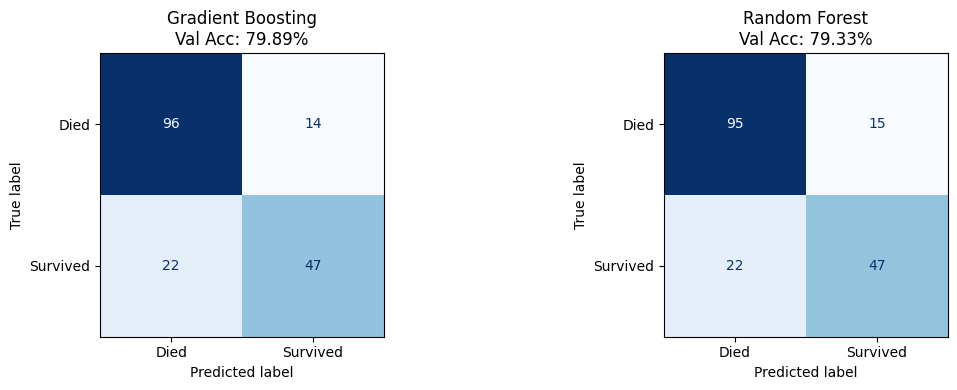

Gradient Boosting:
              precision    recall  f1-score   support

        Died       0.81      0.87      0.84       110
    Survived       0.77      0.68      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



In [47]:
# Confusion Matrix & Classification Report
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt

# Fit on full X_train, evaluate on X_val
gb.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)
y_pred_rf = rf.predict(X_val)

# Confusion matrix for best model
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, preds, name in zip(
    axes,
    [gb, rf],
    [y_pred_gb, y_pred_rf],
    ['Gradient Boosting', 'Random Forest']
):
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Died','Survived'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nVal Acc: {accuracy_score(y_val, preds):.2%}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Full report
print("Gradient Boosting:")
print(classification_report(y_val, y_pred_gb, target_names=['Died','Survived']))

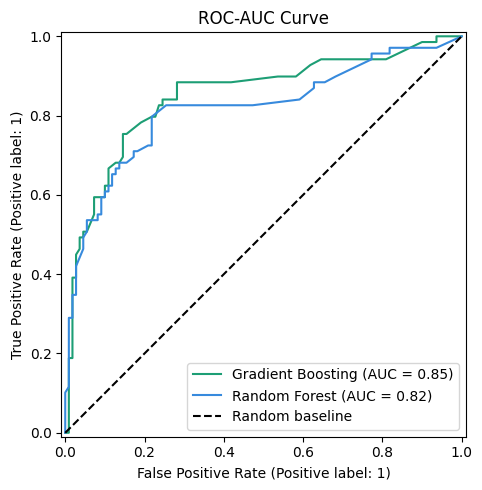

GB  ROC-AUC: 0.8504
RF  ROC-AUC: 0.8175


In [48]:
# ROC-AUC Curve
fig, ax = plt.subplots(figsize=(7, 5))

for model, name, color in [
    (gb, 'Gradient Boosting', '#1D9E75'),
    (rf, 'Random Forest',     '#378ADD'),
]:
    RocCurveDisplay.from_estimator(model, X_val, y_val,
                                    ax=ax, name=name, color=color)

ax.plot([0,1],[0,1], 'k--', label='Random baseline')
ax.set_title('ROC-AUC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"GB  ROC-AUC: {roc_auc_score(y_val, gb.predict_proba(X_val)[:,1]):.4f}")
print(f"RF  ROC-AUC: {roc_auc_score(y_val, rf.predict_proba(X_val)[:,1]):.4f}")

In [49]:
# GridSearchCV tuning
# Tune Random Forest:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,        # use all CPU cores
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Best RF params:    {rf_grid.best_params_}")
print(f"Best RF CV score:  {rf_grid.best_score_:.4f}")
print(f"RF val accuracy:   {accuracy_score(y_val, rf_grid.predict(X_val)):.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF params:    {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV score:  0.8315
RF val accuracy:   0.8156


In [50]:
# Tune Gradient Boosting
gb_params = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [2, 3, 4],
    'subsample':     [0.8, 1.0],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"Best GB params:    {gb_grid.best_params_}")
print(f"Best GB CV score:  {gb_grid.best_score_:.4f}")
print(f"GB val accuracy:   {accuracy_score(y_val, gb_grid.predict(X_val)):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best GB params:    {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best GB CV score:  0.8372
GB val accuracy:   0.8156


In [51]:
# Final model comparison after tuning
tuned_results = {
    'RF (default)':  accuracy_score(y_val, rf.predict(X_val)),
    'RF (tuned)':    accuracy_score(y_val, rf_grid.predict(X_val)),
    'GB (default)':  accuracy_score(y_val, gb.predict(X_val)),
    'GB (tuned)':    accuracy_score(y_val, gb_grid.predict(X_val)),
}

for name, acc in tuned_results.items():
    print(f"{name:<20} {acc:.4f}")

RF (default)         0.7933
RF (tuned)           0.8156
GB (default)         0.7989
GB (tuned)           0.8156


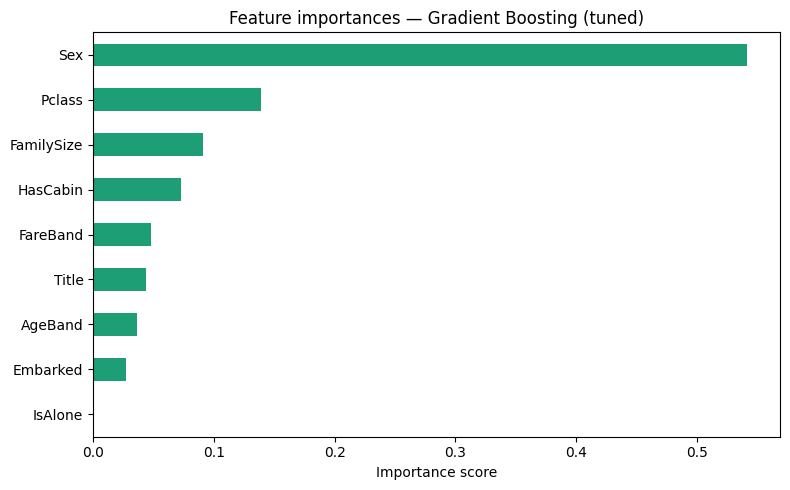

In [52]:
#  Feature importance from best model
best_model = gb_grid.best_estimator_

importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), color='#1D9E75')
plt.title('Feature importances — Gradient Boosting (tuned)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [53]:
# Reload test fresh
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# Step 1 — missing values for test
test['Age']  = test['Age'].fillna(test['Age'].median())
test['Fare'] = test['Fare'].fillna(test['Fare'].median())
test['HasCabin'] = test['Cabin'].notnull().astype(int)
test.drop(columns=['Cabin'], inplace=True)

# Step 2 — feature engineering
test = engineer_features(test)

# Step 3 — encoding
test['Sex']      = test['Sex'].map({'male': 0, 'female': 1})
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test['Title']    = le.transform(test['Title'])
test['AgeBand']  = test['AgeBand'].map({'Child':0,'Teen':1,'YoungAdult':2,'Adult':3,'Senior':4})
test['FareBand'] = test['FareBand'].map({'Low':0,'Mid':1,'High':2,'VeryHigh':3})

# Step 4 — scale and prepare X_test
X_test = test.drop(columns=['PassengerId'])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Step 5 — verify columns match exactly
print("X_test columns:  ", X_test.columns.tolist())
print("X_train columns: ", X_train.columns.tolist())
print("Match:", X_test.columns.tolist() == X_train.columns.tolist())
print(f"\nMissing values: {X_test.isnull().sum().sum()}")

X_test columns:   ['Pclass', 'Sex', 'Embarked', 'HasCabin', 'Title', 'FamilySize', 'IsAlone', 'AgeBand', 'FareBand']
X_train columns:  ['Pclass', 'Sex', 'Embarked', 'HasCabin', 'Title', 'FamilySize', 'IsAlone', 'AgeBand', 'FareBand']
Match: True

Missing values: 0


In [54]:
# Pick the best tuned model
final_model = gb_grid.best_estimator_  # or rf_grid if it scored higher

# Generate Kaggle submission
preds = final_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived':    preds
})

submission.to_csv('/kaggle/working/submission.csv', index=False)

print(submission.head(10))
print(f"\nSubmission shape: {submission.shape}")   # must be (418, 2)
print(f"Predicted survival rate: {preds.mean():.2%}")  # should be ~35–40%

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         0
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Submission shape: (418, 2)
Predicted survival rate: 34.69%


In [55]:
preds = final_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived':    preds
})

submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.head(10))
print(f"Shape: {submission.shape}")           # must be (418, 2)
print(f"Survival rate: {preds.mean():.2%}")   # expect ~35–40%

   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         0
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0
Shape: (418, 2)
Survival rate: 34.69%
